<a href="https://colab.research.google.com/github/CharitoLucero/neurona/blob/main/neurona.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

@author: Octavio Gutiérrez de Código Máquina

URL del canal: https://www.youtube.com/CodigoMaquina

URL del video: https://youtu.be/zBqnWfTwCgc

# Clasificación de Imágenes para Principiantes
# Red Neuronal Convolucional
A las redes neuronales convolucionales comúnmente se les conoce por el término CNNs por sus siglas en inglés (Convolutional Neural Networks).

Antes de ver/ejecutar esta Libreta, se recomienda ver el video sobre clasificación de imágenes con un perceptrón multicapa: https://youtu.be/uM4u7P2xkO8

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Librerías y versión de TensorFlow

In [ ]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random
print(tf.__version__)

2.18.0


In [ ]:
# Ruta donde están almacenadas las imágenes
ruta = "/content/drive/MyDrive/red neuronal/dataset/dataset_500"

In [ ]:
import os
ruta = "/content/drive/MyDrive/red neuronal/dataset/dataset_500"
clase = "A"
i = 0 # The error occurred with i=0 for 'A'

file_path_to_check = os.path.join(ruta, clase, str(i) + ".png")

print(f"Verificando la existencia del archivo: {file_path_to_check}")
if os.path.exists(file_path_to_check):
        print("El archivo EXISTE en la ruta especificada.")
        # Optionally, try opening with a basic file open to see if it's readable
        try:
            with open(file_path_to_check, 'rb') as f:
                print("El archivo es legible.")
        except Exception as e:
            print(f"Error al intentar leer el archivo: {e}")
else:
        print("El archivo NO EXISTE en la ruta especificada según os.path.exists().")
        print("Verificando el contenido del directorio padre:")
        try:
            parent_dir = os.path.join(ruta, clase)
            if os.path.exists(parent_dir):
                print(f"Contenido de {parent_dir}:")
                for item in os.listdir(parent_dir):
                    print(item)
            else:
                print(f"El directorio padre '{parent_dir}' tampoco existe.")
        except Exception as e:
            print(f"Error al listar el directorio padre: {e}")

# Run this code *before* the loop that tries to open the image. This will explicitly check if `os.path.exists` returns True for the exact path causing the error. If it says the file does not exist, carefully compare the printed path with the actual path in your Google Drive interface, paying close attention to spelling, capitalization, and any extra spaces or hidden characters. Listing the directory content might reveal if the folder or file has a slightly different name.
# Check Case Sensitivity of Directory Names: If os.path.exists indicates the file doesn't exist, list the contents of the archive directory to see the exact capitalization of the subdirectories (rock, paper, A).
import os

ruta = "/content/drive/MyDrive/red neuronal/dataset/dataset_500"

print(f"Contenido del directorio archive: {ruta}")
try:
        if os.path.exists(ruta):
            for item in os.listdir(ruta):
                print(item)
        else:
             print(f"El directorio archive '{ruta}' no existe.")
except Exception as e:
        print(f"Error al listar el directorio archive: {e}")

Verificando la existencia del archivo: /content/drive/MyDrive/red neuronal/dataset/dataset_500/A/0.png
El archivo NO EXISTE en la ruta especificada según os.path.exists().
Verificando el contenido del directorio padre:
Contenido de /content/drive/MyDrive/red neuronal/dataset/dataset_500/A:
435.jpg
12.jpg
449.jpg
7.jpg
445.jpg
440.jpg
444.jpg
8.jpg
439.jpg
437.jpg
11.jpg
24.jpg
436.jpg
448.jpg
20.jpg
438.jpg
26.jpg
447.jpg
443.jpg
28.jpg
10.jpg
22.jpg
446.jpg
441.jpg
16.jpg
14.jpg
442.jpg
4.jpg
18.jpg
56.jpg
50.jpg
32.jpg
463.jpg
460.jpg
454.jpg
451.jpg
54.jpg
44.jpg
34.jpg
42.jpg
452.jpg
64.jpg
455.jpg
456.jpg
52.jpg
62.jpg
30.jpg
38.jpg
461.jpg
462.jpg
467.jpg
458.jpg
60.jpg
48.jpg
40.jpg
466.jpg
457.jpg
450.jpg
46.jpg
459.jpg
465.jpg
58.jpg
453.jpg
464.jpg
36.jpg
276.jpg
314.jpg
82.jpg
222.jpg
176.jpg
268.jpg
354.jpg
74.jpg
490.jpg
390.jpg
340.jpg
260.jpg
489.jpg
220.jpg
226.jpg
168.jpg
190.jpg
479.jpg
90.jpg
182.jpg
180.jpg
384.jpg
262.jpg
481.jpg
284.jpg
382.jpg
470.jpg
298.jpg
131

### Cargar Imágenes de *VOCAES*
Se asume que las imágenes están agrupadas por clase y que se encuentran en carpetas diferentes: *A*, *E*,  *I*, *O*, *U*. Además, cada carpeta tiene imágenes cuyo nombre va de 0.jpg a 499.jpg indicando el número de imagen.

In [ ]:
# Descripción de clases y su identificador
descripcion = ("A", "E", "I", "O", "U")
clases = {"A": 0, "E": 1, "I": 2, "O": 3, "U": 4}
num_img_clase = 500

# División entrenamiento/prueba
num_entrena = round(num_img_clase * 0.70)  # 350
num_prueba = num_img_clase - num_entrena   # 150

# Inicializamos arreglos para las 5 clases
# Las imágenes son de 300 (ancho) x 200 (alto) y tienen 3 canales (RGB)
imagenes_entrena = np.empty((num_entrena * len(clases), 200, 300, 3), dtype="uint8")
clases_entrena = np.empty(num_entrena * len(clases), dtype="uint8")

imagenes_prueba = np.empty((num_prueba * len(clases), 200, 300, 3), dtype="uint8")
clases_prueba = np.empty(num_prueba * len(clases), dtype="uint8")

# Cargar imágenes de entrenamiento
for i in range(num_entrena):  # 0 a 349
    for clase in clases:
        img_path = os.path.join(ruta, clase, f"{i}.jpg")
        imagen = Image.open(img_path).convert("RGB").resize((300, 200)) # Redimensionar la imagen a las dimensiones deseadas
        idx = i + clases[clase] * num_entrena
        imagenes_entrena[idx] = np.array(imagen) # Convierte la imagen redimensionada en una matriz NumPy
        clases_entrena[idx] = clases[clase]

# Cargar imágenes de prueba
for i in range(num_entrena, num_img_clase):  # 350 a 499
    for clase in clases:
        img_path = os.path.join(ruta, clase, f"{i}.jpg")
        imagen = Image.open(img_path).convert("RGB").resize((300, 200)) # Redimensionar la imagen a las dimensiones deseadas
        idx = (i - num_entrena) + clases[clase] * num_prueba
        imagenes_prueba[idx] = np.array(imagen) # Convierte la imagen redimensionada en una matriz NumPy
        clases_prueba[idx] = clases[clase]


# Visualización de algunas imágenes

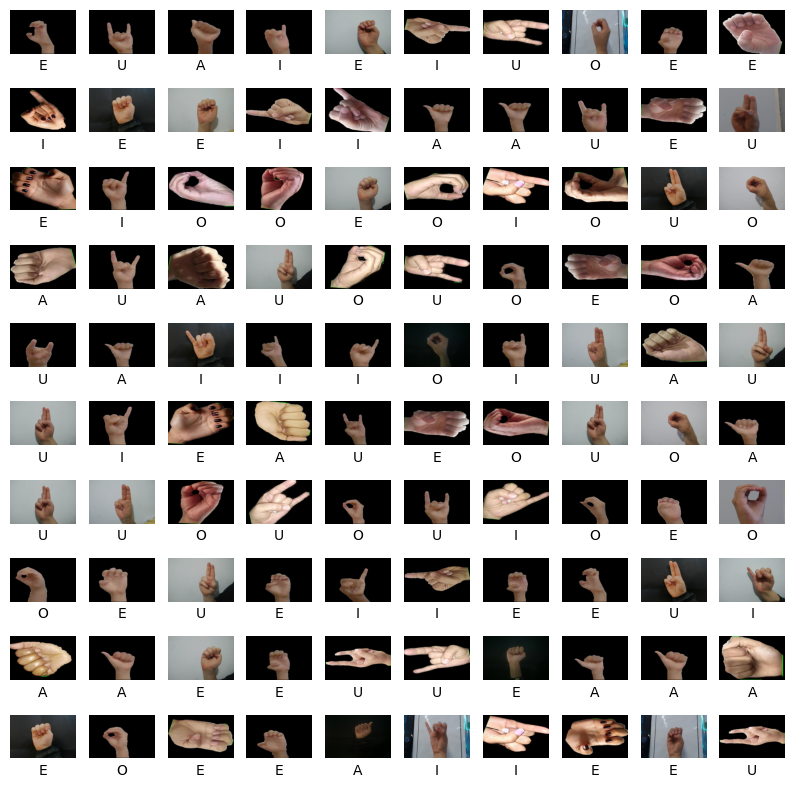

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(100):
    plt.subplot(10, 10, i + 1)
    # Selección aleatoria de una imagen
    indice = random.randint(0, num_entrena*len(clases) - 1)
    plt.imshow(imagenes_entrena[indice], cmap="gray")
    plt.xlabel(descripcion[clases_entrena[indice]])
    plt.grid(False)
    plt.box(False)
    plt.xticks([])
    plt.yticks([])
plt.show()

## Visualización de una imagen arbitraria en tamaño grande

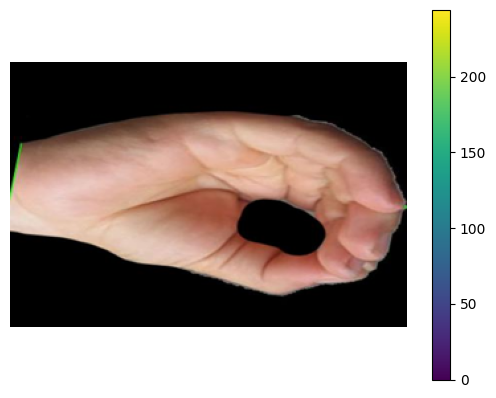

In [ ]:
plt.figure()
plt.imshow(imagenes_prueba[502])
plt.colorbar()
plt.grid(False)
plt.box(False)
plt.grid(False)
plt.xticks([])
plt.yticks([])
plt.show()

### Escalar los píxeles de las imágenes del rango [0, 255] al rango [0, 1]

In [ ]:
imagenes_entrena = imagenes_entrena / 255
imagenes_prueba = imagenes_prueba / 255

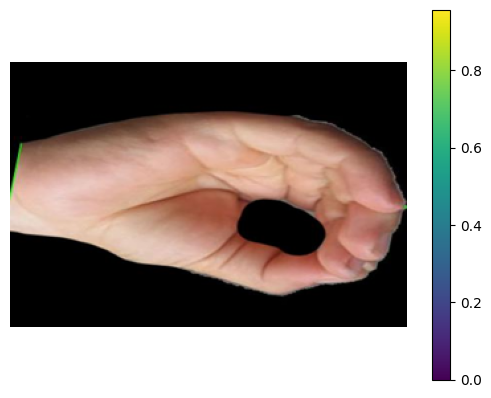

In [ ]:
plt.figure()
plt.imshow(imagenes_prueba[502])
plt.colorbar()
plt.grid(False)
plt.box(False)
plt.grid(False)
plt.xticks([])
plt.yticks([])
plt.show()

# Creación del modelo de la Red Neuronal Convolucional (CNN)

In [ ]:
modelo = tf.keras.Sequential([
    #Prmera capa
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 300, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    #Segunda capa
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    #Tercera capa
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),



    tf.keras.layers.Flatten(), #se aplana la imagen
    tf.keras.layers.Dense(128, activation='relu'), #Dense: Red Neuronal simple. Es una capa oculta completamente conectada con 128 neuronas
                                                   #Activación ReLU (Rectified Linear Unit), que deja pasar solo los valores positivos.
    tf.keras.layers.Dense(5, activation='softmax'),  # 5 clases
                                                     # softmax = convierte la salida en probabilidades de que una imagen pertenezca a cada clase
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


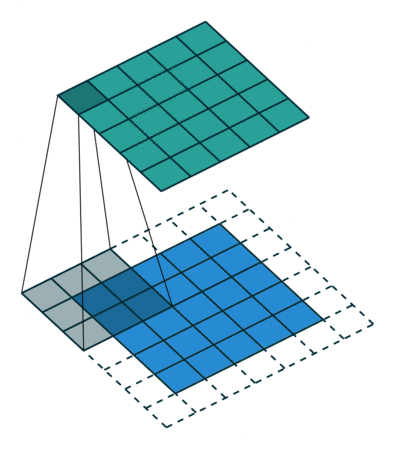

# Cofigurar el Modelo para Entrenamiento

In [ ]:
modelo.compile(optimizer="sgd",  #Este algoritmo ajusta los pesos del modelo durante el entrenamiento para minimizar el error
              loss=tf.keras.losses.SparseCategoricalCrossentropy(), #Define la función de pérdida que el modelo intentará minimizar.
                                                                    #SparseCategoricalCrossentropy: funcion de pérdida para problemas de clasificación multiclase. Cuando las etiquetas son enteros
              metrics=["accuracy"]) #Exactitud del modelo


### Loss

loss (función de pérdida) es un número que mide qué tan mal lo está haciendo el modelo.

Es la diferencia entre la predicción del modelo y el valor real.


Cada vez que el modelo hace una predicción, se compara con el valor correcto (etiqueta real), y el loss calcula el error.



*   Error grande → loss alto
*   Error pequeño → loss bajo




Luego, el modelo ajusta sus pesos para que ese loss se reduzca.

Objetivo: Minimizar loss
Cuanto más bajo, mejor está aprendiendo el modelo.

### Funcion de optimizacion

SGD	                   

Aprendizaje adaptativo: No	       

Usa momentum (memoria del gradiente pasado): No	        

Convergencia: Lenta o inestable	    

Parámetros sensibles: Muy dependiente del LR	(learning rate:si es muy alto, puede divergir; si es bajo, puede ser lento).



Recomendado: Modelos simples,fine-tune  


ADAM

Aprendizaje adaptativo: Sí (ajusta tasa por parámetro)

Usa momentum (memoria del gradiente pasado): Sí (acelera convergencia)

Convergencia: Rápida y estable

Parámetros sensibles: Más tolerante al LR 	(learning rate:si es muy alto, puede divergir; si es bajo, puede ser lento).

Recomendado: Redes profundas, datos  ruidosos, CNNs


# Entrena el Modelo (es decir, la Red Neuronal Convolucional)

In [ ]:
history = modelo.fit(imagenes_entrena, clases_entrena, epochs=20, validation_data=(imagenes_prueba, clases_prueba))  #epochs----> interaciones
                                                                   #¿Cuántas epochs son recomendables?
                                                                   #Cantidad de datos	         Sugerencia de epochs
                                                                   #< 5,000 imágenes	             10–50 epochs
                                                                   #5,000–50,000	                 10–30 epochs
                                                                   #> 50,000	                      5–20 epochs (puede ser suficiente)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 259s 5s/step - accuracy: 0.2560 - loss: 1.6010 - val_accuracy: 0.3227 - val_loss: 1.5650
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 268s 5s/step - accuracy: 0.3794 - loss: 1.5269 - val_accuracy: 0.2533 - val_loss: 1.6381
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 248s 5s/step - accuracy: 0.4357 - loss: 1.4177 - val_accuracy: 0.2680 - val_loss: 1.5744
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 253s 5s/step - accuracy: 0.4990 - loss: 1.2976 - val_accuracy: 0.2973 - val_loss: 1.9721
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 257s 5s/step - accuracy: 0.5603 - loss: 1.1376 - val_accuracy: 0.4213 - val_loss: 1.3385
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 269s 5s/step - accuracy: 0.5726 - loss: 1.0772 - val_accuracy: 0.4293 - val_loss: 1.4223
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 247s 4s/step - accuracy: 0.6417 - loss: 0.9260 - val_accuracy: 0.3800 - val_loss: 1.4018
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 268s 5s/step - accuracy: 0.6833 - loss: 0.8524 - val_accuracy: 0.4093 - v

### Batch


Por qué 55?

Un batch es un grupo de imágenes que el modelo procesa de una vez antes de actualizar los pesos. Se usa para mejorar la eficiencia del entrenamiento.

batch_size (tamaño de lote). Si no se especifica, Keras usa por defecto batch_size=32.

Total de imágenes de entrenamiento (imagenes_entrena) es:
5 clases × 350 imágenes = 1750 imágenes


Entonces:
n_batches = total_imágenes / batch_size = 1750 / 32 ≈ 54.7 ≈ 55

### Resultados del entrenamiento

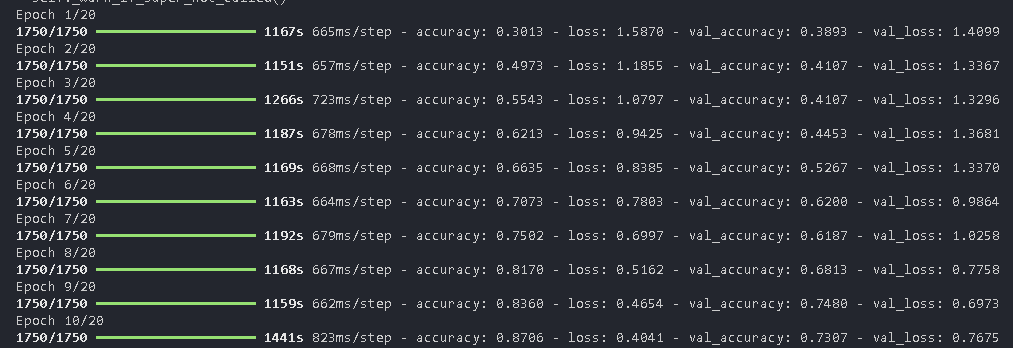

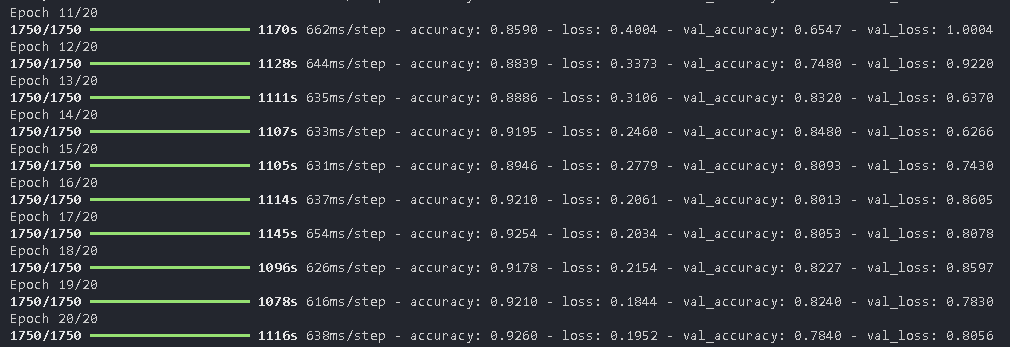

In [ ]:
#Entrenamiento del modelo con Funcion de optimzación Adam

from IPython.display import Image, display

display(Image(filename= "/content/drive/MyDrive/red neuronal/ACCURACY_1.png"))
display(Image(filename= "/content/drive/MyDrive/red neuronal/ACCURACY_2.png"))


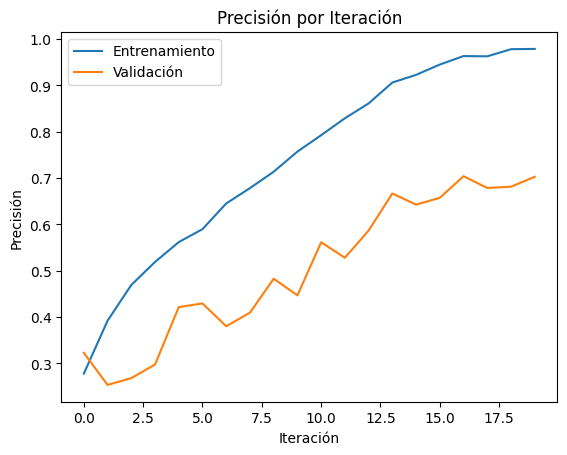

In [ ]:
# Graficar precisión
#Si la precisión de entrenamiento sube y la de validación baja, hay overfitting ⇒ reducir epochs o agregar Dropout*.
#Si ambas suben y aún no se estabilizan ⇒ aumentar epochs.

plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title("Precisión por Iteración")
plt.xlabel("Iteración")
plt.ylabel("Precisión")
plt.legend()
plt.show()


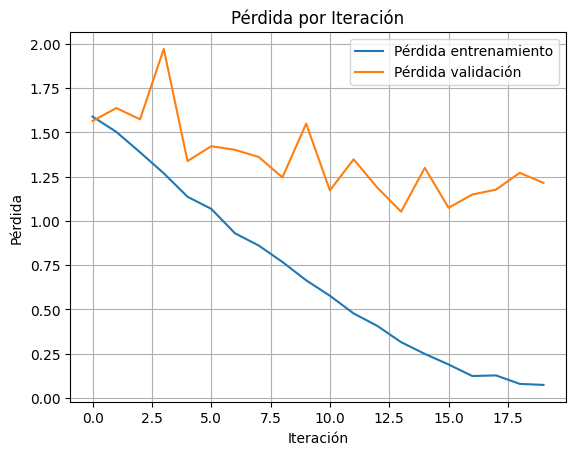

In [ ]:
# Graficar pérdida
plt.plot(history.history['loss'], label='Pérdida entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida validación')
plt.title("Pérdida por Iteración")
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True)
plt.show()

Capa conv2d - filtros: (3, 3, 3, 32)


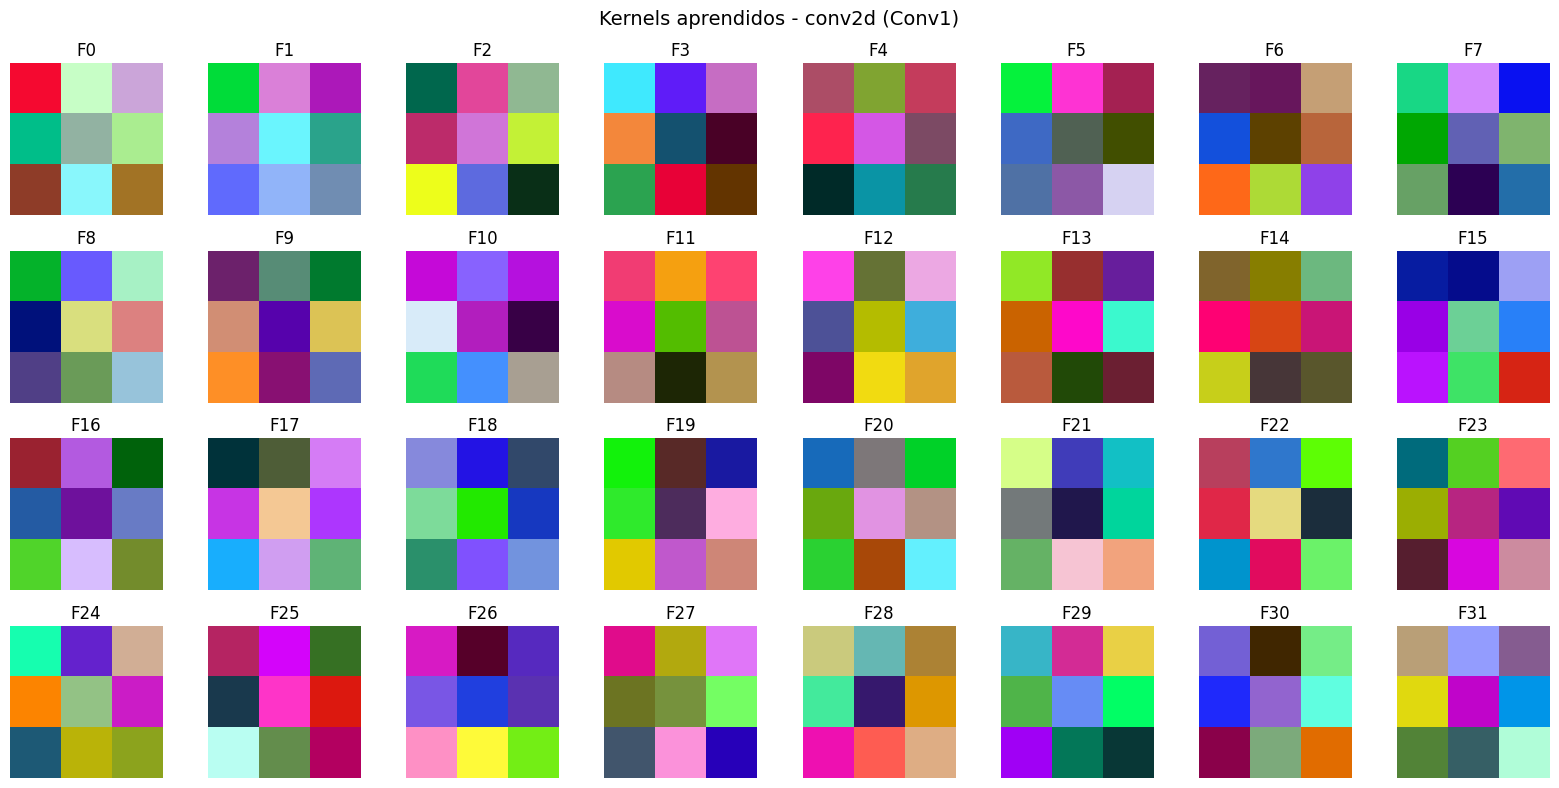

Capa conv2d_1 - filtros: (3, 3, 32, 64)


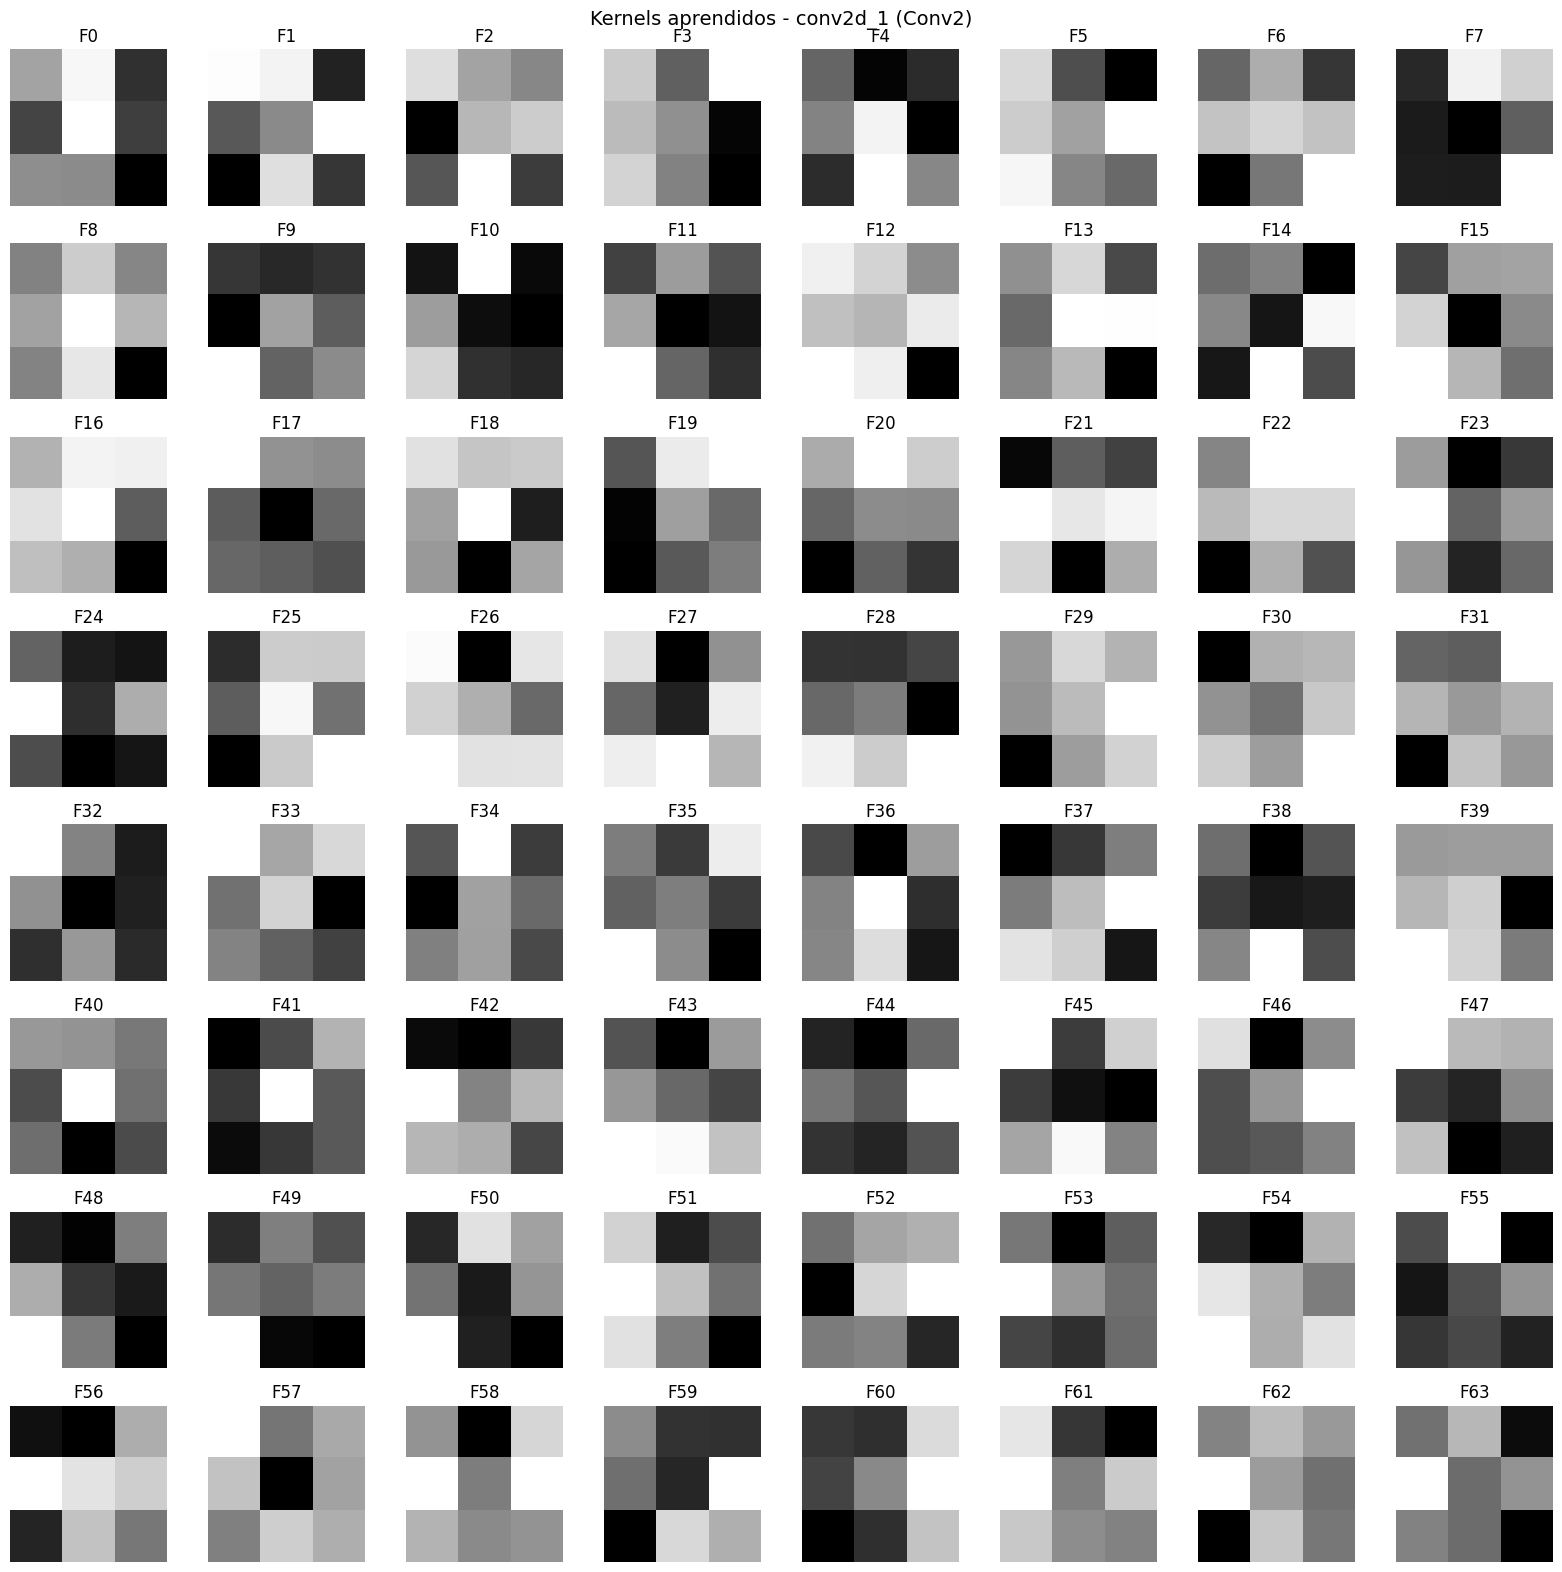

Capa conv2d_2 - filtros: (3, 3, 64, 128)


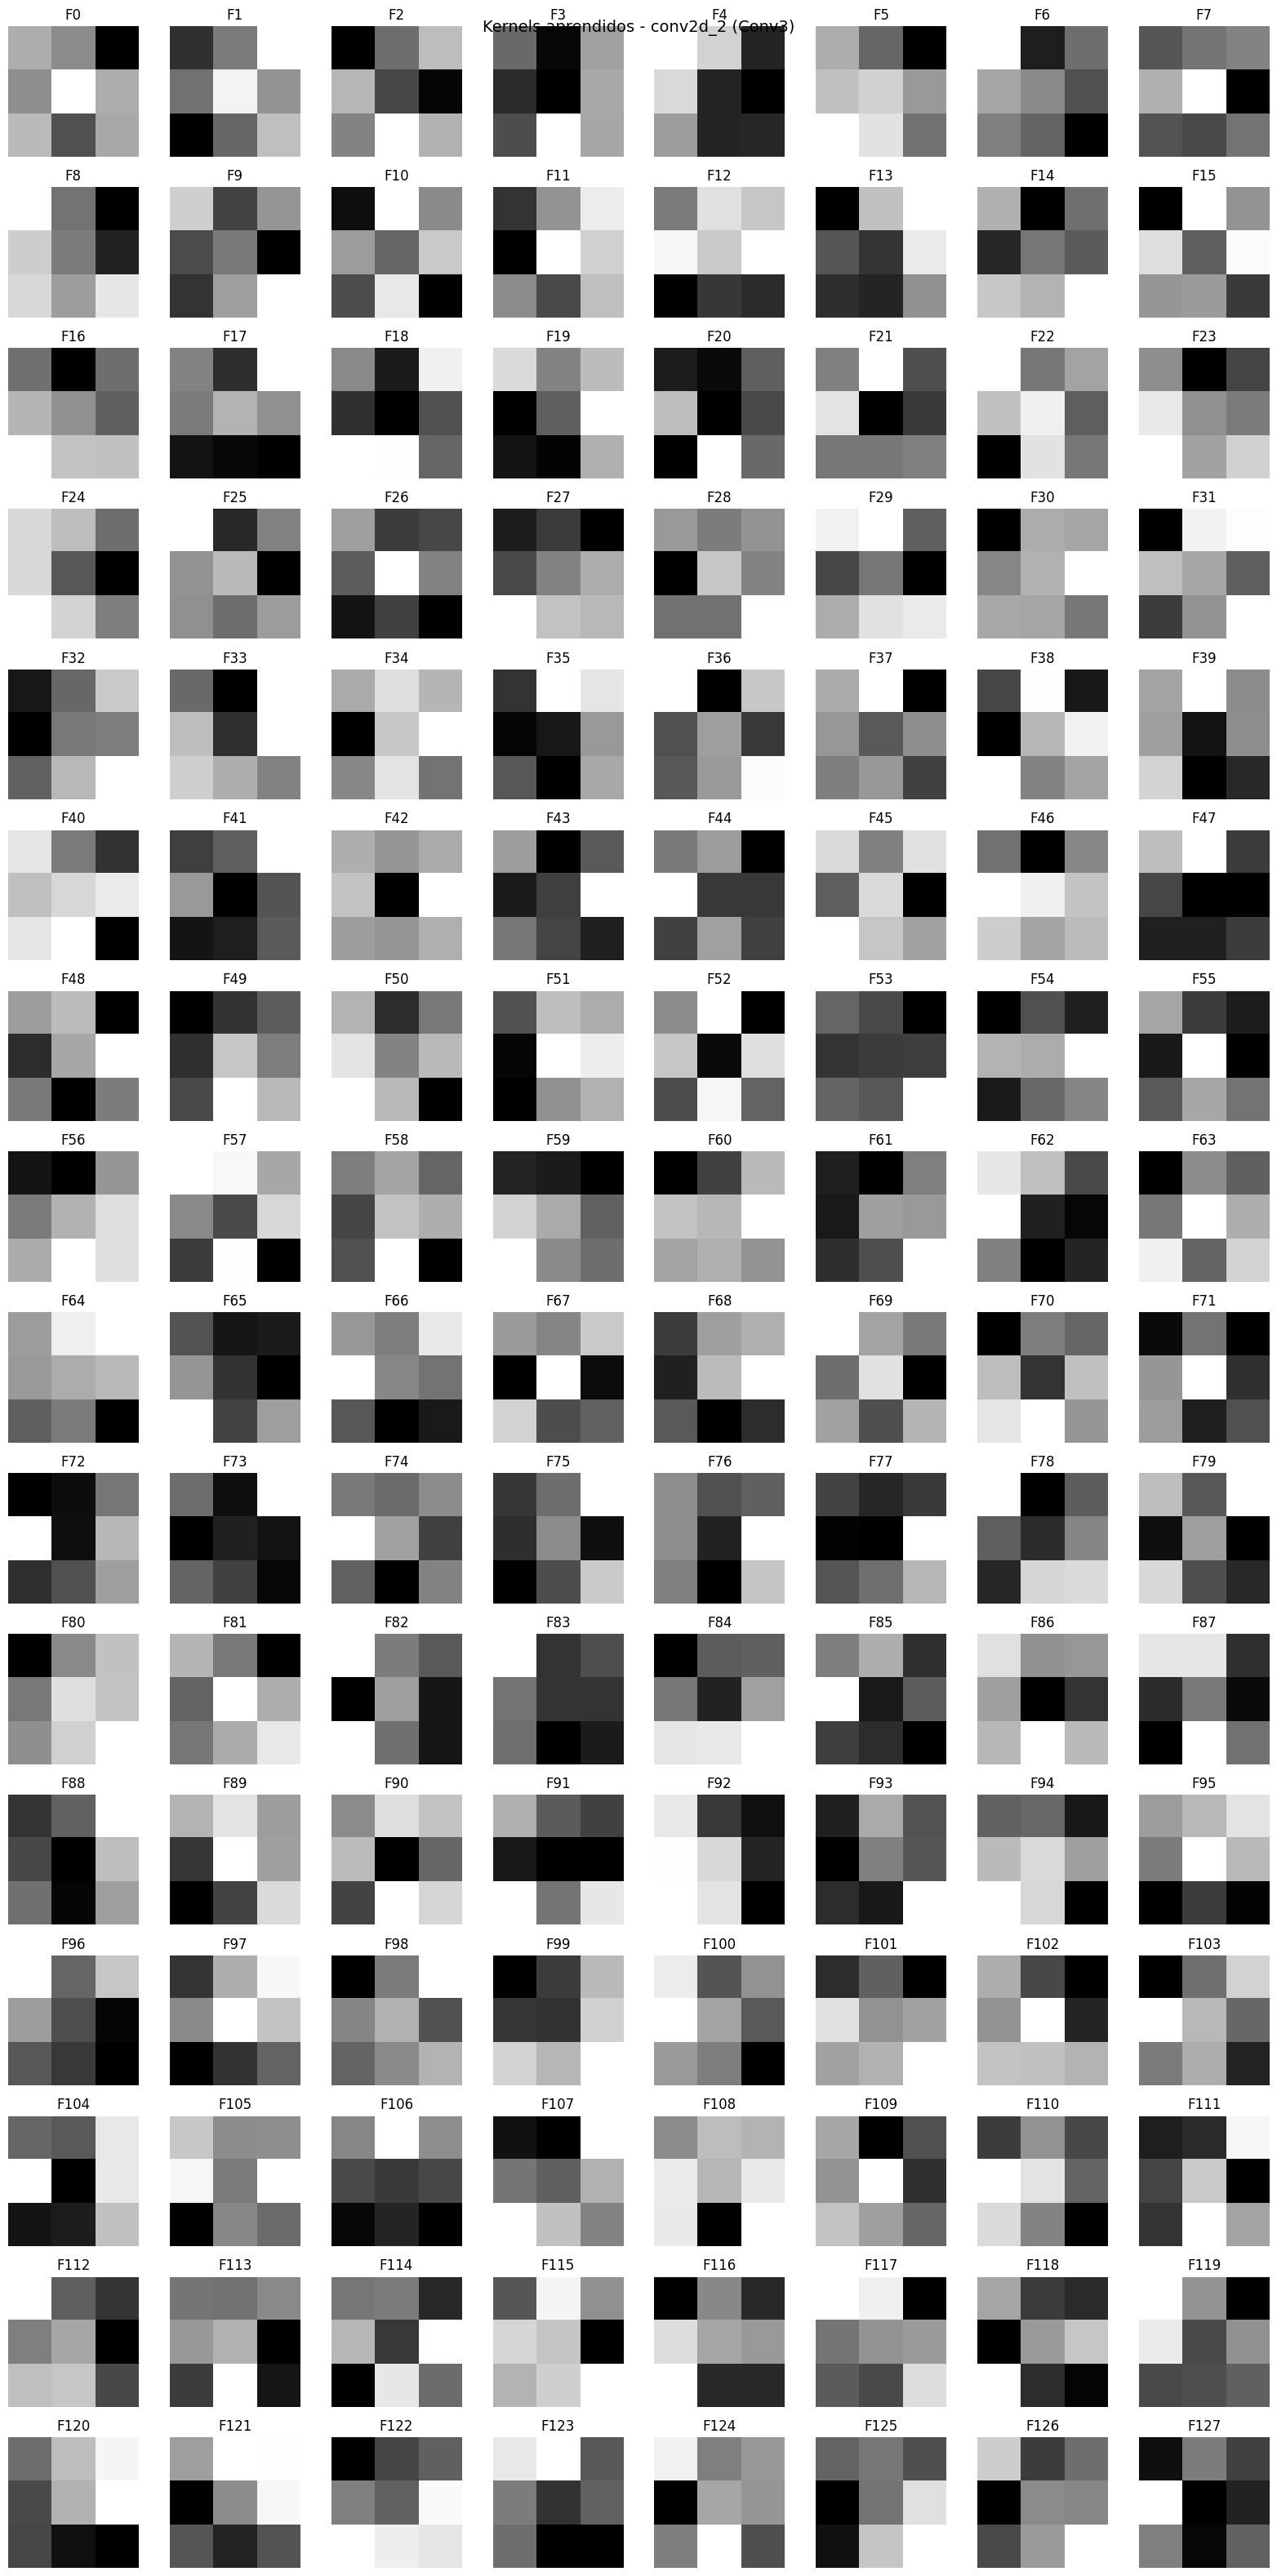

In [ ]:
import math

# Visualizar los kernels capa por capa
def mostrar_todos_los_kernels(modelo):
    conv_index = 0
    for capa in modelo.layers:
        if isinstance(capa, tf.keras.layers.Conv2D):
            pesos, _ = capa.get_weights()
            print(f"Capa {capa.name} - filtros: {pesos.shape}")
            mostrar_kernels_de_capa(pesos, nombre=f"{capa.name} (Conv{conv_index + 1})")
            conv_index += 1

def mostrar_kernels_de_capa(pesos, nombre="Capa"):
    # pesos.shape = (filtro_alto, filtro_ancho, canales_entrada, filtros_salida)
    num_filtros = pesos.shape[-1]
    canales = pesos.shape[2]
    cols = 8
    rows = math.ceil(num_filtros / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()

    for i in range(num_filtros):
        filtro = pesos[:, :, :, i]
        if canales == 3:
            # Filtro RGB: mostrar en color
            filtro_img = (filtro - filtro.min()) / (filtro.max() - filtro.min() + 1e-6)
        else:
            # Más canales: promedio por canal
            filtro_img = filtro.mean(axis=-1)
        axes[i].imshow(filtro_img, cmap=None if canales == 3 else 'gray')
        axes[i].axis('off')
        axes[i].set_title(f'F{i}')

    for j in range(num_filtros, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"Kernels aprendidos - {nombre}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Ejecutar visualización de todas las capas Conv2D
mostrar_todos_los_kernels(modelo)


# Evalúa el modelo (porcentaje de aciertos con datos de prueba)

In [ ]:
perdida, exactitud = modelo.evaluate(imagenes_prueba, clases_prueba)
print("Exactitud (Accuracy) = aciertos_prueba / imagenes_de_prueba):", exactitud)

24/24 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.6859 - loss: 1.3034
Exactitud (Accuracy) = aciertos_prueba / imagenes_de_prueba): 0.7026666402816772


# Clasifica las Imágenes de Prueba con la Red Convolucional

In [ ]:
predicciones = modelo.predict(imagenes_prueba)

24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step


Por qué 24?

Un batch es un grupo de imágenes que el modelo procesa de una vez antes de actualizar los pesos.

batch_size (tamaño de lote). Si no se especifica, Keras usa por defecto batch_size=32.

Total de imágenes de entrenamiento (imagenes_entrena) es: 5 clases × 150 imágenes = 750 imágenes

Entonces: n_batches = total_imágenes / batch_size = 750 / 32 ≈ 23.4375 ≈ 24

# Salida de la Red Neuronal para cada Imagen de Prueba

In [ ]:
# Creación de arreglo para almacenar predicciones
clase_predicha = np.empty(num_prueba * len(clases), dtype = "uint8")

for instancia in range(num_prueba * len(clases)):
  # almacena clase predicha para una imagen dada
  clase_predicha[instancia] = np.argmax(predicciones[instancia])
  if clase_predicha[instancia] == clases_prueba[instancia]:
    print("Probabilidades:", predicciones[instancia],
          "Clase predicha:", clase_predicha[instancia],
          "Clase correcta:", clases_prueba[instancia],
          "La Red Neuronal ACERTÓ")
  else:
    print("Probabilidades:", predicciones[instancia],
          "Clase predicha:", clase_predicha[instancia],
          "Clase correcta:", clases_prueba[instancia],
          "La Red Neuronal ERRÓ")

Probabilidades: [8.910815e-01 9.375022e-03 6.811121e-08 9.954346e-02 5.666864e-10] Clase predicha: 0 Clase correcta: 0 La Red Neuronal ACERTÓ
Probabilidades: [0.92142683 0.04710898 0.00369695 0.02075651 0.00701066] Clase predicha: 0 Clase correcta: 0 La Red Neuronal ACERTÓ
Probabilidades: [6.3908532e-02 7.8875911e-01 4.1743931e-08 1.4733234e-01 4.3217929e-10] Clase predicha: 1 Clase correcta: 0 La Red Neuronal ERRÓ
Probabilidades: [0.9204722  0.04551024 0.00410802 0.02230508 0.00760433] Clase predicha: 0 Clase correcta: 0 La Red Neuronal ACERTÓ
Probabilidades: [9.8754352e-01 9.0192109e-03 4.1031902e-07 3.4370164e-03 4.4390667e-12] Clase predicha: 0 Clase correcta: 0 La Red Neuronal ACERTÓ
Probabilidades: [0.9248558  0.04307699 0.00374955 0.02101969 0.00729801] Clase predicha: 0 Clase correcta: 0 La Red Neuronal ACERTÓ
Probabilidades: [9.8881245e-01 7.2488263e-03 2.0592097e-06 3.9364472e-03 1.6399227e-07] Clase predicha: 0 Clase correcta: 0 La Red Neuronal ACERTÓ
Probabilidades: [0.9275

# Matriz de Confusión: Resultado de Evaluación a Detalle

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

matriz = tf.math.confusion_matrix(clases_prueba, clase_predicha)
print("Matriz de Confusión:\n", matriz.numpy())

Matriz de Confusión:
 [[107  12  16  15   0]
 [ 33 111   0   6   0]
 [ 17   9 105  13   6]
 [ 32  21   1  96   0]
 [  5   6  20  11 108]]


In [ ]:
print(classification_report(clases_prueba, clase_predicha))

              precision    recall  f1-score   support

           0       0.55      0.71      0.62       150
           1       0.70      0.74      0.72       150
           2       0.74      0.70      0.72       150
           3       0.68      0.64      0.66       150
           4       0.95      0.72      0.82       150

    accuracy                           0.70       750
   macro avg       0.72      0.70      0.71       750
weighted avg       0.72      0.70      0.71       750

